In [ ]:
import sys
sys.path.append('/home/shiftpub/Dynamic_AMM/single_step_exp')
from metrics_plot import subplot_comparison, subplot_single_step
import numpy as np
import polars as pl

output_dir = '/home/shiftpub/Dynamic_AMM/single_step_exp/output/combined_metrics.parquet'
df = pl.read_parquet(output_dir)
# print unique metrics
print(f"Unique metrics: {df['metric'].unique()}")


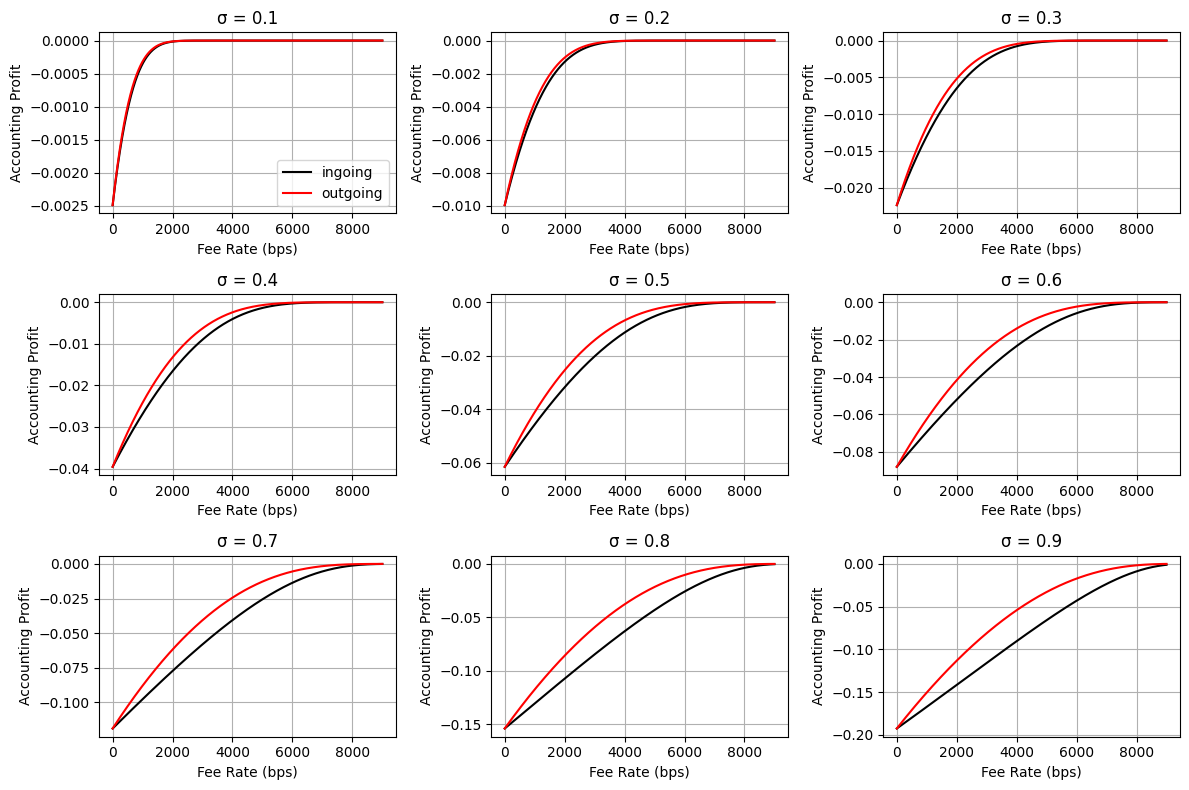

In [17]:
import matplotlib.pyplot as plt

# extract the accounting profit from the output directory
accounting_profit = pl.read_parquet(output_dir).filter(pl.col('metric') == 'accounting_profit',
                                                       pl.col('drift') == 'false')
sigmas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
x_column = 'fee_rate'
x_label = 'Fee Rate (bps)'
x_scale = 10000  # Convert to bps

# Line styles for each fee source
styles = {
    'ingoing': ('black', '-', 'Incoming'),
    'outgoing': ('red', '-', 'Outgoing')
}

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# Plot for each sigma
for i, sigma in enumerate(sigmas):
    ax = axes[i]
    
    # Filter data for current sigma
    sigma_data = accounting_profit.filter(pl.col('sigma') == sigma)
    # Plot incoming and outgoing trades
    for trade_type, (color, linestyle, label) in styles.items():
        trade_data = sigma_data.filter(pl.col('fee_source') == trade_type)
        x_values = trade_data[x_column].to_numpy() * x_scale
        y_values = trade_data['value'].to_numpy()        
        ax.plot(x_values, y_values, color=color, linestyle=linestyle, label=label)
    
    ax.set_title(f'σ = {sigma}')
    ax.set_xlabel(x_label)
    ax.set_ylabel('Accounting Profit')
    ax.grid(True)
    
    # Add legend to first subplot only
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
subplot_single_step(output_dir, 'accounting_profit')

## 1. Expected Fee

In [ ]:
metric = 'accounting_profit'
subplot_comparison(output_dir,
                metric=metric)
# plot_value_and_vega_comparison(path=output_dir, metric=metric)

## 2. Pool Value

In [ ]:
metric = 'pool_value'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

## 3. Trader PNL

In [ ]:
metric = 'trader_pnl'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

## 4. Impermanent Loss

In [ ]:
metric = 'impermanent_loss'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

In [6]:
## 5. Net Profit

In [ ]:
metric = 'net_profit'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

## 6. Accounting Profit

In [ ]:
metric = 'accounting_profit'
subplot_comparison(output_dir,
                metric=metric,
                drift=False,
                plot_rows=3,
                max_plots=1,
                value_type='value',
                subplot_by='sigma',
                max_sigma=2.0)
plot_value_and_vega_comparison(path=output_dir, metric=metric)

In [ ]:
import numpy as np
from scipy.stats import lognorm
from scipy.integrate import quad
import matplotlib.pyplot as plt

def calculate_pnl_components(f: float, sigma: float, ls: float = 1.0):
    """Calculate both integrals separately and their sum"""
    
    def integrand1(v, f, ls):
        # First integral: (1 - sqrt(v/(1-f)))^2
        return ls * (1 - np.sqrt(v/(1-f)))**2 * lognorm.pdf(v, s=sigma, scale=np.exp(-0.5*sigma**2))
    
    def integrand2(v, f, ls):
        # Second integral: (sqrt(v) - sqrt(1/(1-f)))^2
        return ls * (np.sqrt(v) - np.sqrt(1/(1-f)))**2 * lognorm.pdf(v, s=sigma, scale=np.exp(-0.5*sigma**2))
    
    # Calculate first integral from 0 to 1-f
    result1, _ = quad(integrand1, 1e-4, 1-f, args=(f, ls))
    
    # Calculate second integral from 1/(1-f) to infinity
    result2, _ = quad(integrand2, 1/(1-f), np.inf, args=(f, ls))
    
    return result1, result2, result1 + result2

# Test parameters
f = 0.005  # Fixed fee rate
sigma_values = np.linspace(0.1, 5.0, 100)  # Range of sigma values

# Calculate results for different sigma values
results = [calculate_pnl_components(f, sigma) for sigma in sigma_values]
integral1_values = [r[0] for r in results]
integral2_values = [r[1] for r in results]
total_values = [r[2] for r in results]

# Create the visualization
plt.figure(figsize=(12, 8))

# Plot each component
plt.plot(sigma_values, integral1_values, 'b-', label='First Integral (0 to 1-f)', linewidth=2)
plt.plot(sigma_values, integral2_values, 'r-', label='Second Integral (1/(1-f) to ∞)', linewidth=2)
plt.plot(sigma_values, total_values, 'g--', label='Total PnL', linewidth=2)

plt.xlabel('Volatility (σ)')
plt.ylabel('Expected PnL')
plt.title(f'Components of Expected PnL vs Volatility (f = {f})')
plt.legend()
plt.grid(True)

# Add a table with numerical values
print("\nNumerical Values:")
print("σ\t\tFirst Integral\tSecond Integral\tTotal PnL")
print("-" * 60)
for i in range(len(sigma_values)):
    print(f"{sigma_values[i]:.2f}\t\t{integral1_values[i]:.6f}\t{integral2_values[i]:.6f}\t{total_values[i]:.6f}")

plt.show()


In [ ]:
import numpy as np
from scipy.stats import lognorm, norm
import matplotlib.pyplot as plt

def plot_lognormal_and_normal():
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Range of x values
    x_lognormal = np.linspace(0.0001, 2, 1000)  # for lognormal
    x_normal = np.linspace(-2, 2, 1000)        # for normal
    
    # Different sigma values to show
    sigma_values = [0.1, 0.25, 0.5, 0.75]
    colors = ['blue', 'red', 'green', 'purple']
    
    # First subplot: Log-normal distribution
    for sigma, color in zip(sigma_values, colors):
        # For lognormal with μ = -σ²/2
        scale = np.exp(-0.5 * sigma**2)
        pdf_lognormal = lognorm.pdf(x_lognormal, s=sigma, scale=scale)
        
        ax1.plot(x_lognormal, pdf_lognormal, color=color, 
                label=f'σ = {sigma}', linewidth=2)
    
    # ax1.axvline(x=1, color='black', linestyle='--', alpha=0.3)
    ax1.set_xlabel('v')
    ax1.set_ylabel('Probability Density')
    ax1.set_title('Log-normal Distribution\n(μ = -σ²/2)')
    ax1.legend()
    ax1.grid(True)
    
    # Second subplot: Normal distribution (log transform)
    for sigma, color in zip(sigma_values, colors):
        # Normal distribution with μ = -σ²/2
        pdf_normal = norm.pdf(x_normal, loc=-0.5*sigma**2, scale=sigma)
        
        ax2.plot(x_normal, pdf_normal, color=color, 
                label=f'σ = {sigma}, μ = {-0.5*sigma**2:.2f}', linewidth=2)
    
    # ax2.axvline(x=0, color='black', linestyle='--', alpha=0.3)
    ax2.set_xlabel('ln(v)')
    ax2.set_ylabel('Probability Density')
    ax2.set_title('Normal Distribution\n(after taking natural log)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Print some key statistics
    print("\nKey Statistics:")
    print("σ\tLognormal\t\t\tNormal")
    print("\tMean\tMedian\tMode\t\tMean\tMedian/Mode")
    print("-" * 70)
    for sigma in sigma_values:
        # Lognormal stats
        ln_mean = 1.0  # always 1 due to μ = -σ²/2
        ln_median = np.exp(-0.5 * sigma**2)
        ln_mode = np.exp(-0.5 * sigma**2 - sigma**2)
        
        # Normal stats (after log transform)
        n_mean = -0.5 * sigma**2  # μ
        n_median = n_mean  # median = mode = mean for normal distribution
        
        print(f"{sigma:.1f}\t{ln_mean:.3f}\t{ln_median:.3f}\t{ln_mode:.3f}\t\t{n_mean:.3f}\t{n_median:.3f}")

# Create the plots
plot_lognormal_and_normal()